<a href="https://colab.research.google.com/github/crystalclcm/JobPostings/blob/main/University_skills.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.dcu.ie/courses/undergraduate/business-school/accounting-and-finance#prospectus-structure"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

# Example: Extract overview
overview_section = soup.find("div", {"class": "field--name-body"})
if overview_section:
    text = overview_section.get_text(separator=" ", strip=True)
    data.append(["DCU", "Accounting & Finance", "Overview", text, url])

# Example: Extract modules
modules = soup.find_all("div", {"class": "module"})
for m in modules:
    module_name = m.find("h3").get_text(strip=True) if m.find("h3") else ""
    module_desc = m.get_text(separator=" ", strip=True)
    data.append(["DCU", "Accounting & Finance", module_name, module_desc, url])

df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("dcu_accounting.csv", index=False)


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.tcd.ie/scss/courses/undergraduate/computer-science/course-structure/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["TCD", "Computer Science", section, text, url])

# 1. Extract overview
overview = soup.find("div", {"class": "field--name-body"})
if overview:
    text = overview.get_text(separator=" ", strip=True)
    add_row("Overview", text)

# 2. Extract module sections (headers + following text)
headers = soup.find_all(["h3", "h4"])
for h in headers:
    module_name = h.get_text(strip=True)
    desc_block = h.find_next_sibling("div")
    if desc_block:
        desc_text = desc_block.get_text(separator=" ", strip=True)
        add_row(f"Module: {module_name}", desc_text)

# 3. Extract expandable <details> sections
details_blocks = soup.find_all("details")
for block in details_blocks:
    summary = block.find("summary")
    if summary:
        section_name = summary.get_text(strip=True)
        content = block.get_text(separator=" ", strip=True)
        add_row(f"Expandable: {section_name}", content)

# 4. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("tcd_computer_science.csv", index=False)

print("Saved: tcd_computer_science.csv")


Saved: tcd_computer_science.csv


In [4]:
!pip install pdfplumber


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.2 MB/s eta 0:00:00


In [5]:
import requests
import pdfplumber
import pandas as pd
from io import BytesIO

url = "https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf"

# Step 1: Download PDF
response = requests.get(url)
pdf_file = BytesIO(response.content)

# Step 2: Extract text
full_text = ""
with pdfplumber.open(pdf_file) as pdf:
    for page in pdf.pages:
        page_text = page.extract_text()
        if page_text:
            full_text += page_text + "\n"

# Step 3: Split into sections
sections = []
current_section = "General"

for line in full_text.split("\n"):
    line = line.strip()

    # Detect section headers
    if "Module Description" in line:
        current_section = "Module Description"
    elif "Learning Outcomes" in line:
        current_section = "Learning Outcomes"
    elif "On completion of this module" in line:
        current_section = "Learning Outcomes"

    # Save line
    if line:
        sections.append(["TCD", "BESS", current_section, line, url])

# Step 4: Save to CSV
df = pd.DataFrame(sections, columns=["university", "course", "section", "text", "url"])
df.to_csv("tcd_bess.csv", index=False)

print("Saved: tcd_bess.csv")


Saved: tcd_bess.csv


In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.universityofgalway.ie/courses/undergraduate-courses/commerce.html#information"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["Galway", "Commerce", section, text, url])

# 1. Extract main overview
overview = soup.find("div", {"class": "course-introduction"})
if overview:
    text = overview.get_text(separator=" ", strip=True)
    add_row("Overview", text)

# 2. Extract all section headers + content
sections = soup.find_all("div", {"class": "accordion-item"})
for sec in sections:
    header = sec.find("h3")
    content = sec.find("div", {"class": "accordion-content"})

    if header and content:
        section_name = header.get_text(strip=True)
        section_text = content.get_text(separator=" ", strip=True)
        add_row(section_name, section_text)

# 3. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("galway_commerce.csv", index=False)

print("Saved: galway_commerce.csv")



Saved: galway_commerce.csv


In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.ul.ie/courses/bachelor-business-studies#modules"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["UL", "Business Studies", section, text, url])

# 1. Extract module blocks
modules = soup.find_all("div", {"class": "module-item"})

for m in modules:
    # Module title
    title = m.find("h3")
    module_name = title.get_text(strip=True) if title else "Unknown Module"

    # Module description
    desc = m.find("div", {"class": "module-description"})
    desc_text = desc.get_text(separator=" ", strip=True) if desc else ""

    add_row(f"Module: {module_name}", desc_text)

    # Learning outcomes (if present)
    lo = m.find("div", {"class": "learning-outcomes"})
    if lo:
        lo_text = lo.get_text(separator=" ", strip=True)
        add_row(f"Learning Outcomes: {module_name}", lo_text)

# 2. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("ul_business.csv", index=False)

print("Saved: ul_business.csv")


Saved: ul_business.csv


In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.tudublin.ie/study/undergraduate/courses/accounting-tu670/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["TU Dublin", "Accounting", section, text, url])

# 1. Extract overview (usually in a main content div)
overview = soup.find("div", {"class": "course-introduction"})
if overview:
    text = overview.get_text(separator=" ", strip=True)
    add_row("Overview", text)

# 2. Extract accordion sections (Course Content, What You Will Study, etc.)
accordion_items = soup.find_all("div", {"class": "accordion-item"})
for item in accordion_items:
    header = item.find("h3")
    content = item.find("div", {"class": "accordion-content"})

    if header and content:
        section_name = header.get_text(strip=True)
        section_text = content.get_text(separator=" ", strip=True)
        add_row(section_name, section_text)

# 3. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("tud_accounting.csv", index=False)

print("Saved: tud_accounting.csv")


Saved: tud_accounting.csv


In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.dcu.ie/courses/undergraduate/school-computing/computer-science"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["DCU", "Computer Science", section, text, url])

# 1. Extract overview
overview = soup.find("div", {"class": "field--name-body"})
if overview:
    text = overview.get_text(separator=" ", strip=True)
    add_row("Overview", text)

# 2. Extract module sections (headers + following text)
headers = soup.find_all(["h2", "h3", "h4"])
for h in headers:
    section_name = h.get_text(strip=True)

    # Find the next content block
    content = h.find_next_sibling("div")
    if content:
        section_text = content.get_text(separator=" ", strip=True)
        add_row(section_name, section_text)

# 3. Extract expandable sections (if present)
details_blocks = soup.find_all("details")
for block in details_blocks:
    summary = block.find("summary")
    if summary:
        section_name = summary.get_text(strip=True)
        content = block.get_text(separator=" ", strip=True)
        add_row(f"Expandable: {section_name}", content)

# 4. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("dcu_computer_science.csv", index=False)

print("Saved: dcu_computer_science.csv")


Saved: dcu_computer_science.csv


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.ul.ie/courses/bsc-computer-science"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["UL", "Computer Science", section, text, url])

# 1. Extract overview
overview = soup.find("div", {"class": "course-introduction"})
if overview:
    text = overview.get_text(separator=" ", strip=True)
    add_row("Overview", text)

# 2. Extract accordion sections (Course Content, What You Will Study, etc.)
accordion_items = soup.find_all("div", {"class": "accordion-item"})
for item in accordion_items:
    header = item.find("h3")
    content = item.find("div", {"class": "accordion-content"})

    if header and content:
        section_name = header.get_text(strip=True)
        section_text = content.get_text(separator=" ", strip=True)
        add_row(section_name, section_text)

# 3. Extract module blocks (UL sometimes lists modules separately)
modules = soup.find_all("div", {"class": "module-item"})
for m in modules:
    title = m.find("h3")
    module_name = title.get_text(strip=True) if title else "Unknown Module"

    desc = m.find("div", {"class": "module-description"})
    desc_text = desc.get_text(separator=" ", strip=True) if desc else ""

    add_row(f"Module: {module_name}", desc_text)

    lo = m.find("div", {"class": "learning-outcomes"})
    if lo:
        lo_text = lo.get_text(separator=" ", strip=True)
        add_row(f"Learning Outcomes: {module_name}", lo_text)

# 4. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("ul_computer_science.csv", index=False)

print("Saved: ul_computer_science.csv")


Saved: ul_computer_science.csv


In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.tudublin.ie/study/undergraduate/courses/computing-tu856/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["TU Dublin", "Computer Science", section, text, url])

# 1. Extract overview
overview = soup.find("div", {"class": "course-introduction"})
if overview:
    text = overview.get_text(separator=" ", strip=True)
    add_row("Overview", text)

# 2. Extract accordion sections (Course Content, What You Will Study, etc.)
accordion_items = soup.find_all("div", {"class": "accordion-item"})
for item in accordion_items:
    header = item.find("h3")
    content = item.find("div", {"class": "accordion-content"})

    if header and content:
        section_name = header.get_text(strip=True)
        section_text = content.get_text(separator=" ", strip=True)
        add_row(section_name, section_text)

# 3. Extract module blocks (if TU Dublin lists modules separately)
modules = soup.find_all("div", {"class": "module-item"})
for m in modules:
    title = m.find("h3")
    module_name = title.get_text(strip=True) if title else "Unknown Module"

    desc = m.find("div", {"class": "module-description"})
    desc_text = desc.get_text(separator=" ", strip=True) if desc else ""

    add_row(f"Module: {module_name}", desc_text)

# 4. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("tud_computer_science.csv", index=False)

print("Saved: tud_computer_science.csv")


Saved: tud_computer_science.csv


In [13]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.universityofgalway.ie/courses/undergraduate-courses/computer-science.html"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

data = []

def add_row(section, text):
    data.append(["Galway", "Computer Science", section, text, url])

# 1. Extract overview
overview = soup.find("div", {"class": "course-introduction"})
if overview:
    text = overview.get_text(separator=" ", strip=True)
    add_row("Overview", text)

# 2. Extract accordion sections (Course Outline, Why Choose This Course, etc.)
accordion_items = soup.find_all("div", {"class": "accordion-item"})
for item in accordion_items:
    header = item.find("h3")
    content = item.find("div", {"class": "accordion-content"})

    if header and content:
        section_name = header.get_text(strip=True)
        section_text = content.get_text(separator=" ", strip=True)
        add_row(section_name, section_text)

# 3. Extract module blocks (if listed)
modules = soup.find_all("div", {"class": "module-item"})
for m in modules:
    title = m.find("h3")
    module_name = title.get_text(strip=True) if title else "Unknown Module"

    desc = m.find("div", {"class": "module-description"})
    desc_text = desc.get_text(separator=" ", strip=True) if desc else ""

    add_row(f"Module: {module_name}", desc_text)

# 4. Save CSV
df = pd.DataFrame(data, columns=["university", "course", "section", "text", "url"])
df.to_csv("galway_computer_science.csv", index=False)

print("Saved: galway_computer_science.csv")


Saved: galway_computer_science.csv


In [14]:
import pandas as pd
import glob

files = glob.glob("*.csv")

dfs = [pd.read_csv(f) for f in files]

combined = pd.concat(dfs, ignore_index=True)

combined.to_csv("all_universities_raw.csv", index=False)

print("Saved: all_universities_raw.csv")


Saved: all_universities_raw.csv


In [16]:
import pandas as pd
import re

df = pd.read_csv("all_universities_raw.csv")

df["text"] = df["text"].fillna("")

def clean(t):
    t = t.lower()
    t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

df["clean_text"] = df["text"].apply(clean)

df.to_csv("all_universities_clean.csv", index=False)

print("Saved: all_universities_clean.csv")


Saved: all_universities_clean.csv


In [17]:
import pandas as pd

df = pd.read_csv("all_universities_raw.csv")

df.head(20)


,university,course,section,text,url
0,TCD,BESS,General,School of Business and School of,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
1,TCD,BESS,General,Social Sciences and Philosophy,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
2,TCD,BESS,General,B.A.,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
3,TCD,BESS,General,Moderatorship in,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
4,TCD,BESS,General,Economic and,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
5,TCD,BESS,General,Social Studies,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
6,TCD,BESS,General,(BESS) Handbook,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
7,TCD,BESS,General,2025–2026,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
8,TCD,BESS,General,Contents,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
9,TCD,BESS,General,A note on this handbook .........................,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...


In [18]:
df.shape


(4347, 5)

In [19]:
cognitive = [
    "problem solving",
    "critical thinking",
    "analytical thinking",
    "analysis",
    "evaluation",
    "decision making",
    "logical reasoning",
    "creativity",
    "innovation",
    "strategic thinking",
    "attention to detail",
    "numerical reasoning",
    "research skills",
    "independent learning",
    "judgement",
    "synthesis",
    "interpretation",
    "planning",
    "organisation"
]


In [20]:
social = [
    "teamwork",
    "communication",
    "collaboration",
    "leadership",
    "interpersonal skills",
    "presentation skills",
    "negotiation",
    "conflict resolution",
    "stakeholder management",
    "professionalism",
    "time management",
    "adaptability",
    "empathy",
    "customer service",
    "networking",
    "project management",
    "facilitation",
    "mentoring",
    "cooperation"
]


In [21]:
technical_cs = [
    "python",
    "java",
    "c++",
    "c",
    "javascript",
    "html",
    "css",
    "sql",
    "database",
    "data structures",
    "algorithms",
    "machine learning",
    "artificial intelligence",
    "ai",
    "cloud computing",
    "cybersecurity",
    "networking",
    "software engineering",
    "web development",
    "mobile development",
    "operating systems",
    "data analytics",
    "big data",
    "devops",
    "version control",
    "git",
    "api",
    "testing",
    "debugging"
]


In [22]:
technical_business = [
    "financial accounting",
    "management accounting",
    "auditing",
    "taxation",
    "corporate finance",
    "economics",
    "statistics",
    "data analysis",
    "excel",
    "financial modelling",
    "risk management",
    "business analytics",
    "marketing analytics",
    "supply chain",
    "operations management",
    "project management tools",
    "erp systems",
    "business intelligence",
    "report writing"
]


In [23]:
technical = technical_cs + technical_business


In [25]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("all_universities_clean.csv")

# --- Ensure clean_text is always a string ---
df["clean_text"] = df["clean_text"].fillna("").astype(str)

# --- Skill dictionaries ---
cognitive = [
    "problem solving", "critical thinking", "analytical thinking", "analysis",
    "evaluation", "decision making", "logical reasoning", "creativity",
    "innovation", "strategic thinking", "attention to detail",
    "numerical reasoning", "research skills", "independent learning",
    "judgement", "synthesis", "interpretation", "planning", "organisation"
]

social = [
    "teamwork", "communication", "collaboration", "leadership",
    "interpersonal skills", "presentation skills", "negotiation",
    "conflict resolution", "stakeholder management", "professionalism",
    "time management", "adaptability", "empathy", "customer service",
    "networking", "project management", "facilitation", "mentoring",
    "cooperation"
]

technical_cs = [
    "python", "java", "c++", "c", "javascript", "html", "css", "sql",
    "database", "data structures", "algorithms", "machine learning",
    "artificial intelligence", "ai", "cloud computing", "cybersecurity",
    "networking", "software engineering", "web development",
    "mobile development", "operating systems", "data analytics",
    "big data", "devops", "version control", "git", "api", "testing",
    "debugging"
]

technical_business = [
    "financial accounting", "management accounting", "auditing", "taxation",
    "corporate finance", "economics", "statistics", "data analysis", "excel",
    "financial modelling", "risk management", "business analytics",
    "marketing analytics", "supply chain", "operations management",
    "project management tools", "erp systems", "business intelligence",
    "report writing"
]

technical = technical_cs + technical_business

# --- Matching function ---
def match_skills(text, skills):
    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found

# --- Apply matching ---
df["technical_skills"] = df["clean_text"].apply(lambda x: match_skills(x, technical))
df["cognitive_skills"] = df["clean_text"].apply(lambda x: match_skills(x, cognitive))
df["social_skills"] = df["clean_text"].apply(lambda x: match_skills(x, social))

# --- Save ---
df.to_csv("all_universities_with_skills.csv", index=False)

print("Saved: all_universities_with_skills.csv")


Saved: all_universities_with_skills.csv


In [26]:
import pandas as pd

# Load dataset with skill tags
df = pd.read_csv("all_universities_with_skills.csv")

# Convert stringified lists back to real lists if needed
def fix_list(x):
    if isinstance(x, str):
        x = x.strip("[]")
        if x == "":
            return []
        return [i.strip().strip("'").strip('"') for i in x.split(",")]
    return x

df["technical_skills"] = df["technical_skills"].apply(fix_list)
df["cognitive_skills"] = df["cognitive_skills"].apply(fix_list)
df["social_skills"] = df["social_skills"].apply(fix_list)

# Function to explode and count
def explode_and_count(df, col):
    exploded = df.explode(col)
    exploded = exploded[exploded[col].notna() & (exploded[col] != "")]
    return exploded.groupby(["university", "course", col]).size().reset_index(name="count")

# Generate counts
tech_counts = explode_and_count(df, "technical_skills")
cog_counts = explode_and_count(df, "cognitive_skills")
soc_counts = explode_and_count(df, "social_skills")

# Save outputs
tech_counts.to_csv("technical_skill_counts.csv", index=False)
cog_counts.to_csv("cognitive_skill_counts.csv", index=False)
soc_counts.to_csv("social_skill_counts.csv", index=False)

print("Saved: technical_skill_counts.csv")
print("Saved: cognitive_skill_counts.csv")
print("Saved: social_skill_counts.csv")


Saved: technical_skill_counts.csv
Saved: cognitive_skill_counts.csv
Saved: social_skill_counts.csv


In [28]:
technical = [s for s in technical if len(s) > 1]


In [30]:
import pandas as pd

df = pd.read_csv("all_universities_clean.csv")
df.columns


Index(['university', 'course', 'section', 'text', 'url', 'clean_text'], dtype='object')

In [31]:
import pandas as pd
import re

df = pd.read_csv("all_universities_raw.csv")

def clean(t):
    if not isinstance(t, str):
        return ""
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\b[a-z]\b", " ", t)   # remove single letters
    t = re.sub(r"\s+", " ", t)
    return t.strip()

df["clean_text"] = df["text"].apply(clean)

df.to_csv("all_universities_clean.csv", index=False)

print("Saved: all_universities_clean.csv")


Saved: all_universities_clean.csv


In [32]:
df = pd.read_csv("all_universities_clean.csv")
df["clean_text"] = df["clean_text"].fillna("").astype(str)


In [33]:
def clean(t):
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\b[a-z]\b", " ", t)   # remove single letters
    t = re.sub(r"\s+", " ", t)
    return t.strip()


In [34]:
import pandas as pd
import re

# ---------------------------------------------------------
# 1. LOAD RAW COMBINED DATASET
# ---------------------------------------------------------
df = pd.read_csv("all_universities_raw.csv")

# ---------------------------------------------------------
# 2. CLEAN TEXT (remove noise, lowercase, remove single letters)
# ---------------------------------------------------------
def clean(t):
    if not isinstance(t, str):
        return ""
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)      # keep only letters/numbers
    t = re.sub(r"\b[a-z]\b", " ", t)        # remove single letters (fixes "c")
    t = re.sub(r"\s+", " ", t)              # collapse spaces
    return t.strip()

df["clean_text"] = df["text"].apply(clean)

df.to_csv("all_universities_clean.csv", index=False)
print("Saved cleaned file: all_universities_clean.csv")

# ---------------------------------------------------------
# 3. ENSURE CLEAN_TEXT IS STRING
# ---------------------------------------------------------
df["clean_text"] = df["clean_text"].fillna("").astype(str)

# ---------------------------------------------------------
# 4. SKILL DICTIONARIES (SEPARATED)
# ---------------------------------------------------------

# Cognitive skills
cognitive = [
    "problem solving", "critical thinking", "analytical thinking", "analysis",
    "evaluation", "decision making", "logical reasoning", "creativity",
    "innovation", "strategic thinking", "attention to detail",
    "numerical reasoning", "research skills", "independent learning",
    "judgement", "synthesis", "interpretation", "planning", "organisation"
]

# Social skills
social = [
    "teamwork", "communication", "collaboration", "leadership",
    "interpersonal skills", "presentation skills", "negotiation",
    "conflict resolution", "stakeholder management", "professionalism",
    "time management", "adaptability", "empathy", "customer service",
    "networking", "project management", "facilitation", "mentoring",
    "cooperation"
]

# Technical skills — CS only
technical_cs = [
    "python", "java", "c++", "javascript", "html", "css", "sql",
    "database", "data structures", "algorithms", "machine learning",
    "artificial intelligence", "ai", "cloud computing", "cybersecurity",
    "networking", "software engineering", "web development",
    "mobile development", "operating systems", "data analytics",
    "big data", "devops", "version control", "git", "api", "testing",
    "debugging"
]

# Technical skills — Business only
technical_business = [
    "financial accounting", "management accounting", "auditing", "taxation",
    "corporate finance", "economics", "statistics", "data analysis", "excel",
    "financial modelling", "risk management", "business analytics",
    "marketing analytics", "supply chain", "operations management",
    "project management tools", "erp systems", "business intelligence",
    "report writing"
]

# ---------------------------------------------------------
# 5. MATCHING FUNCTION
# ---------------------------------------------------------
def match_skills(text, skills):
    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found

# ---------------------------------------------------------
# 6. APPLY MATCHING (SEPARATE CATEGORIES)
# ---------------------------------------------------------
df["technical_cs"] = df["clean_text"].apply(lambda x: match_skills(x, technical_cs))
df["technical_business"] = df["clean_text"].apply(lambda x: match_skills(x, technical_business))
df["cognitive_skills"] = df["clean_text"].apply(lambda x: match_skills(x, cognitive))
df["social_skills"] = df["clean_text"].apply(lambda x: match_skills(x, social))

# ---------------------------------------------------------
# 7. SAVE FINAL DATASET
# ---------------------------------------------------------
df.to_csv("all_universities_with_skills.csv", index=False)
print("Saved final file: all_universities_with_skills.csv")


Saved cleaned file: all_universities_clean.csv
Saved final file: all_universities_with_skills.csv


/tmp/ipykernel_5290/173835996.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")


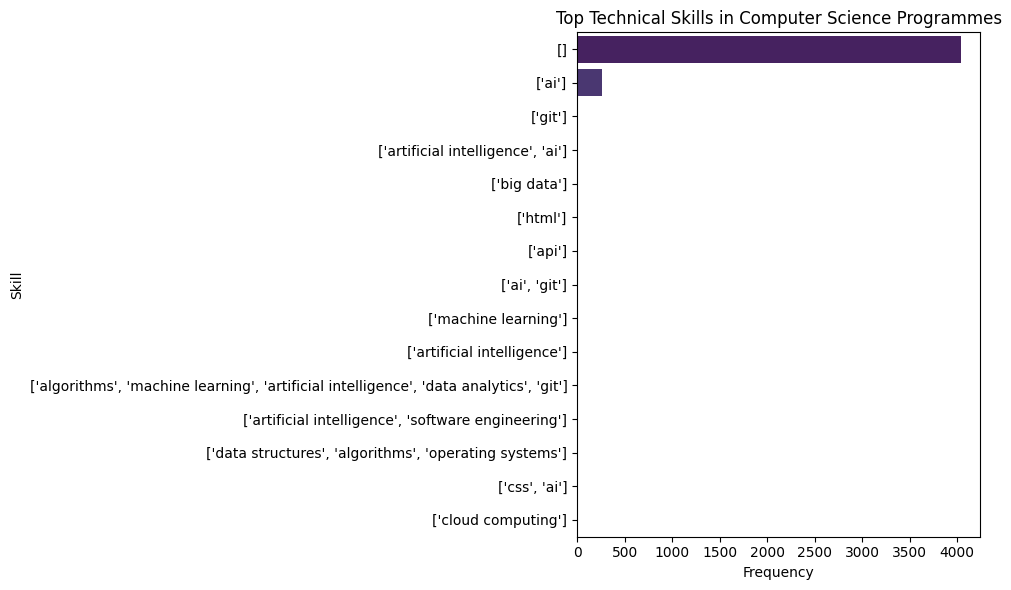

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("all_universities_with_skills.csv")

# explode CS technical skills
cs = df.explode("technical_cs")
cs = cs[cs["technical_cs"].notna() & (cs["technical_cs"] != "")]

top_cs = cs.groupby("technical_cs").size().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")
plt.title("Top Technical Skills in Computer Science Programmes")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


/tmp/ipykernel_5290/1047435762.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")


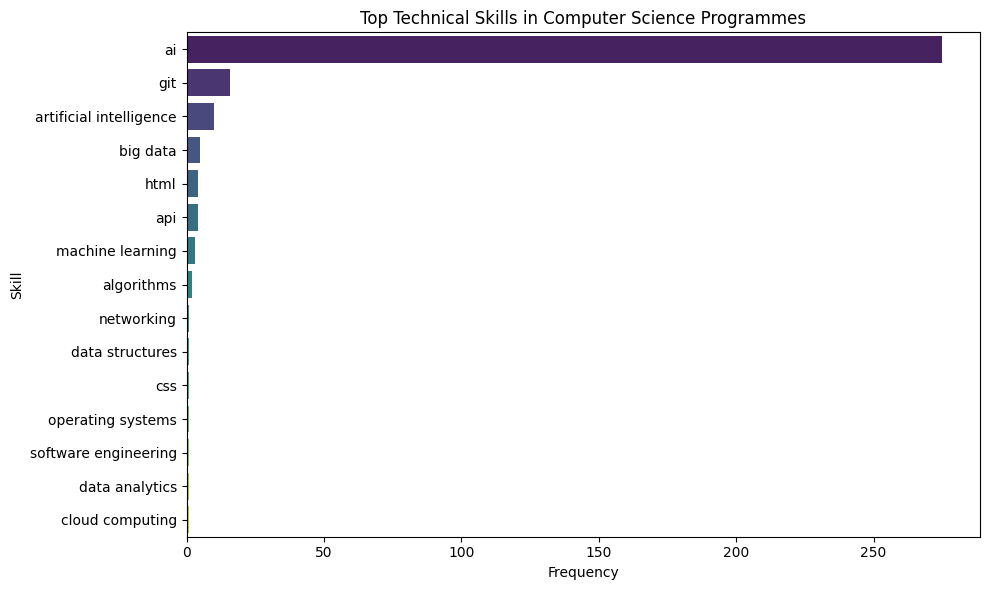

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# Load
df = pd.read_csv("all_universities_with_skills.csv")

# Convert stringified lists to real lists
def to_list(x):
    if pd.isna(x) or x == "" or x == "[]":
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

for col in ["technical_cs", "technical_business", "cognitive_skills", "social_skills"]:
    df[col] = df[col].apply(to_list)

# Explode CS technical skills
cs = df.explode("technical_cs")

# Drop empties
cs = cs[cs["technical_cs"].notna() & (cs["technical_cs"] != "")]

# Count top skills
top_cs = cs["technical_cs"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")
plt.title("Top Technical Skills in Computer Science Programmes")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


In [37]:
import re

def match_skills(text, skills):
    found = []
    for skill in skills:
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern, text):
            found.append(skill)
    return found


In [38]:
synonyms = {
    "machine learning": ["ml"],
    "artificial intelligence": ["ai", "a.i"],
    "data structures": ["ds"],
    "algorithms": ["algo"],
    "software engineering": ["se"],
    "operating systems": ["os"],
}


In [39]:
import pandas as pd
import re
import ast

# ---------------------------------------------------------
# 1. LOAD CLEANED DATASET
# ---------------------------------------------------------
df = pd.read_csv("all_universities_clean.csv")

# Ensure clean_text is string
df["clean_text"] = df["clean_text"].fillna("").astype(str)

# ---------------------------------------------------------
# 2. SKILL DICTIONARIES + SYNONYMS
# ---------------------------------------------------------

technical_cs = {
    "python": ["py"],
    "java": [],
    "c++": ["cpp"],
    "javascript": ["js"],
    "html": [],
    "css": [],
    "sql": [],
    "database": ["databases"],
    "data structures": ["ds"],
    "algorithms": ["algo", "algorithmic"],
    "machine learning": ["ml"],
    "artificial intelligence": ["ai", "a.i"],
    "cloud computing": ["cloud"],
    "cybersecurity": ["security"],
    "networking": ["networks"],
    "software engineering": ["se"],
    "web development": ["webdev"],
    "mobile development": ["android", "ios"],
    "operating systems": ["os"],
    "data analytics": ["analytics"],
    "big data": [],
    "devops": [],
    "version control": ["git"],
    "api": ["apis"],
    "testing": ["test"],
    "debugging": ["debug"]
}

technical_business = {
    "financial accounting": [],
    "management accounting": [],
    "auditing": [],
    "taxation": ["tax"],
    "corporate finance": [],
    "economics": ["economic"],
    "statistics": ["statistical"],
    "data analysis": ["analysis"],
    "excel": ["spreadsheets"],
    "financial modelling": ["modelling"],
    "risk management": ["risk"],
    "business analytics": ["analytics"],
    "marketing analytics": [],
    "supply chain": [],
    "operations management": [],
    "project management tools": ["project management"],
    "erp systems": ["erp"],
    "business intelligence": ["bi"],
    "report writing": ["reports"]
}

cognitive = [
    "problem solving", "critical thinking", "analytical thinking", "analysis",
    "evaluation", "decision making", "logical reasoning", "creativity",
    "innovation", "strategic thinking", "attention to detail",
    "numerical reasoning", "research skills", "independent learning",
    "judgement", "synthesis", "interpretation", "planning", "organisation"
]

social = [
    "teamwork", "communication", "collaboration", "leadership",
    "interpersonal skills", "presentation skills", "negotiation",
    "conflict resolution", "stakeholder management", "professionalism",
    "time management", "adaptability", "empathy", "customer service",
    "networking", "project management", "facilitation", "mentoring",
    "cooperation"
]

# ---------------------------------------------------------
# 3. EXPAND SYNONYMS INTO FULL MATCH LISTS
# ---------------------------------------------------------

def expand_skill_dict(d):
    expanded = {}
    for skill, syns in d.items():
        expanded[skill] = [skill] + syns
    return expanded

technical_cs_expanded = expand_skill_dict(technical_cs)
technical_business_expanded = expand_skill_dict(technical_business)

# ---------------------------------------------------------
# 4. FUZZY MATCHING FUNCTION
# ---------------------------------------------------------

def fuzzy_match(text, skill_dict):
    found = []
    for skill, variants in skill_dict.items():
        for v in variants:
            pattern = r"\b" + re.escape(v) + r"\b"
            if re.search(pattern, text):
                found.append(skill)
                break
    return list(set(found))

# ---------------------------------------------------------
# 5. APPLY MATCHING
# ---------------------------------------------------------

df["technical_cs"] = df["clean_text"].apply(lambda x: fuzzy_match(x, technical_cs_expanded))
df["technical_business"] = df["clean_text"].apply(lambda x: fuzzy_match(x, technical_business_expanded))

df["cognitive_skills"] = df["clean_text"].apply(lambda x: fuzzy_match(x, {s:[s] for s in cognitive}))
df["social_skills"] = df["clean_text"].apply(lambda x: fuzzy_match(x, {s:[s] for s in social}))

# ---------------------------------------------------------
# 6. SAVE FINAL DATASET
# ---------------------------------------------------------

df.to_csv("all_universities_with_skills_upgraded.csv", index=False)
print("Saved upgraded file: all_universities_with_skills_upgraded.csv")


Saved upgraded file: all_universities_with_skills_upgraded.csv


In [40]:
import pandas as pd
df = pd.read_csv("all_universities_with_skills_upgraded.csv")
df.head()


,university,course,section,text,url,clean_text,technical_cs,technical_business,cognitive_skills,social_skills
0,TCD,BESS,General,School of Business and School of,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,school of business and school of,[],[],[],[]
1,TCD,BESS,General,Social Sciences and Philosophy,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,social sciences and philosophy,[],[],[],[]
2,TCD,BESS,General,B.A.,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,NaN,[],[],[],[]
3,TCD,BESS,General,Moderatorship in,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,moderatorship in,[],[],[],[]
4,TCD,BESS,General,Economic and,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,economic and,[],['economics'],[],[]


In [41]:
df["technical_cs"].apply(type).value_counts()


,count
technical_cs,
<class 'str'>,4347


In [42]:
df["technical_cs"].apply(len).value_counts().head(10)


,count
technical_cs,
2,4226
14,85
27,12
12,5
18,5
8,4
19,2
34,2
21,2


In [49]:
df["clean_text"] = df["clean_text"].fillna("").astype(str)


In [50]:
def fuzzy_match(text, skill_dict):
    if not isinstance(text, str):
        text = ""
    found = []
    for skill, variants in skill_dict.items():
        for v in variants:
            pattern = r"\b" + re.escape(v).replace("\\ ", "[ -]?") + r"(s|ing|ed)?\b"
            if re.search(pattern, text):
                found.append(skill)
                break
    return list(set(found))


In [51]:
df["technical_cs"] = df["clean_text"].apply(lambda x: fuzzy_match(x, technical_cs_expanded))


/tmp/ipykernel_5290/1120480336.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")


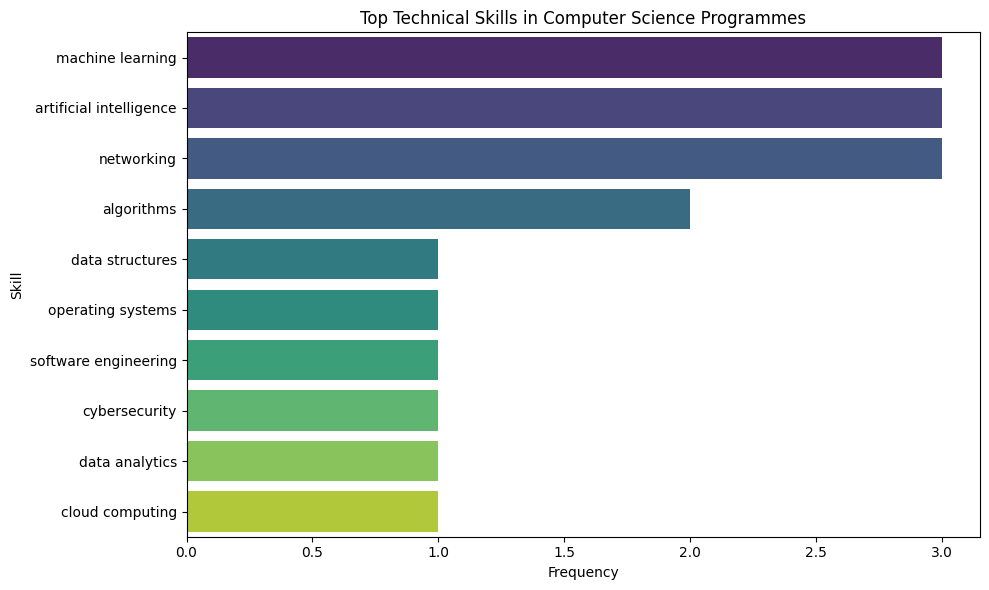

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

cs_only = df[df["course"].str.contains("Computer", case=False)]

cs = cs_only.explode("technical_cs")
cs = cs[cs["technical_cs"].notna() & (cs["technical_cs"] != "")]

top_cs = cs["technical_cs"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")
plt.title("Top Technical Skills in Computer Science Programmes")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


In [54]:
technical_business = {
    "financial accounting": ["accounting", "financial accounts"],
    "management accounting": ["managerial accounting"],
    "auditing": ["audit"],
    "taxation": ["tax", "tax systems"],
    "corporate finance": ["finance", "financial management"],
    "economics": ["economic", "microeconomics", "macroeconomics"],
    "statistics": ["statistical", "stats"],
    "data analysis": ["analysis", "analytical techniques"],
    "excel": ["spreadsheets", "spreadsheet modelling"],
    "financial modelling": ["modelling", "models"],
    "risk management": ["risk", "compliance"],
    "business analytics": ["analytics"],
    "marketing analytics": ["marketing analysis"],
    "supply chain": ["operations", "logistics"],
    "operations management": ["operations"],
    "project management tools": ["project management"],
    "erp systems": ["erp"],
    "business intelligence": ["bi"],
    "report writing": ["reports", "reporting"]
}


In [58]:
df["course"].unique()


array(['BESS', 'Accounting & Finance', 'Computer Science'], dtype=object)

In [59]:
business_only = df[df["course"].isin(["BESS", "Accounting & Finance"])]


/tmp/ipykernel_5290/3606834608.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bus.values, y=top_bus.index, palette="magma")


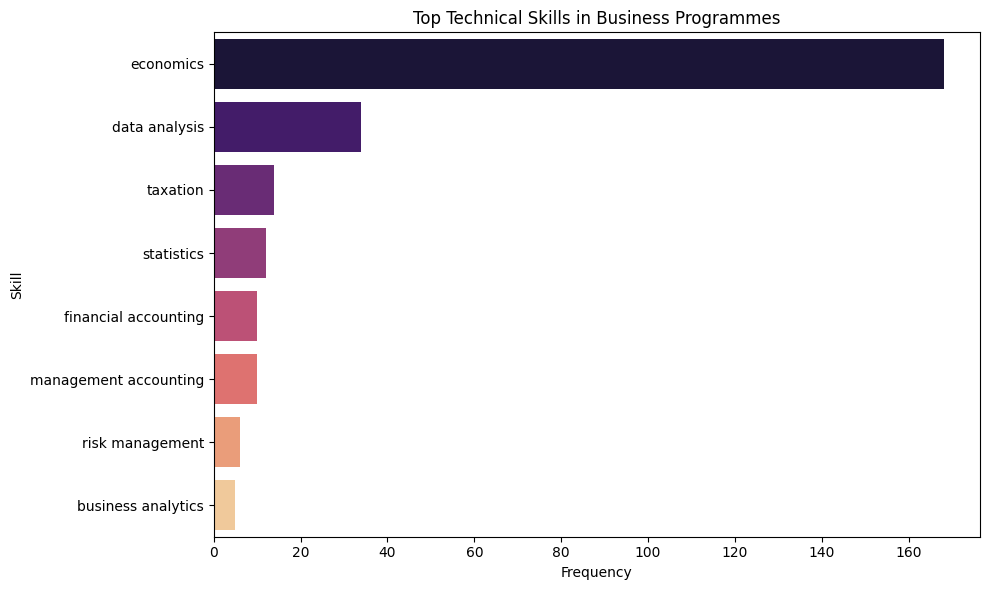

In [60]:
bus = business_only.explode("technical_business")
bus = bus[bus["technical_business"].notna() & (bus["technical_business"] != "")]

top_bus = bus["technical_business"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_bus.values, y=top_bus.index, palette="magma")
plt.title("Top Technical Skills in Business Programmes")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


In [64]:
whos


Variable                      Type             Data/Info
--------------------------------------------------------
BeautifulSoup                 type             <class 'bs4.BeautifulSoup'>
BytesIO                       type             <class '_io.BytesIO'>
accordion_items               ResultSet        []
add_row                       function         <function add_row at 0x7ddb520eea20>
ast                           module           <module 'ast' from '/usr/lib/python3.12/ast.py'>
bus                           DataFrame             university course   <...>\n[259 rows x 10 columns]
business_only                 DataFrame             university          <...>n[4321 rows x 10 columns]
clean                         function         <function clean at 0x7ddb51867380>
cog_counts                    DataFrame           university            <...>        innovation      1
cognitive                     list             n=19
col                           str              social_skills
combined

In [65]:
combined.to_csv("university_skills_final.csv", index=False)


In [66]:
from google.colab import files
files.download("university_skills_final.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
combined.to_csv("university_skills_final.csv", index=False)


In [68]:
from google.colab import files
files.download("university_skills_final.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
combined.to_csv("university_skills_final.csv", index=False)


In [70]:
whos


Variable                      Type             Data/Info
--------------------------------------------------------
BeautifulSoup                 type             <class 'bs4.BeautifulSoup'>
BytesIO                       type             <class '_io.BytesIO'>
accordion_items               ResultSet        []
add_row                       function         <function add_row at 0x7ddb520eea20>
ast                           module           <module 'ast' from '/usr/lib/python3.12/ast.py'>
bus                           DataFrame             university course   <...>\n[259 rows x 10 columns]
business_only                 DataFrame             university          <...>n[4321 rows x 10 columns]
clean                         function         <function clean at 0x7ddb51867380>
cog_counts                    DataFrame           university            <...>        innovation      1
cognitive                     list             n=19
col                           str              social_skills
combined

In [71]:
combined.to_csv("university_skills_final.csv", index=False)


In [72]:
from google.colab import files
files.download("university_skills_final.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
combined.head()
combined.columns
combined.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4347 entries, 0 to 4346
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   university  4347 non-null   object
 1   course      4347 non-null   object
 2   section     4347 non-null   object
 3   text        4301 non-null   object
 4   url         4347 non-null   object
dtypes: object(5)
memory usage: 169.9+ KB


In [74]:
df.columns
df.head()


,university,course,section,text,url,clean_text,technical_cs,technical_business,cognitive_skills,social_skills
0,TCD,BESS,General,School of Business and School of,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,school of business and school of,[],[],[],[]
1,TCD,BESS,General,Social Sciences and Philosophy,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,social sciences and philosophy,[],[],[],[]
2,TCD,BESS,General,B.A.,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,,[],[],[],[]
3,TCD,BESS,General,Moderatorship in,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,moderatorship in,[],[],[],[]
4,TCD,BESS,General,Economic and,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...,economic and,[],[economics],[],[]


In [75]:
df["technical_cs"] = df["clean_text"].apply(lambda x: match_skills(x, technical_cs_expanded))
df["technical_business"] = df["clean_text"].apply(lambda x: match_skills(x, technical_business_expanded))
df["cognitive_skills"] = df["clean_text"].apply(lambda x: match_skills(x, cognitive))
df["social_skills"] = df["clean_text"].apply(lambda x: match_skills(x, social))


In [76]:
df[["technical_cs", "technical_business", "cognitive_skills", "social_skills"]].head(20)


,technical_cs,technical_business,cognitive_skills,social_skills
0,[],[],[],[]
1,[],[],[],[]
2,[],[],[],[]
3,[],[],[],[]
4,[],[],[],[]
5,[],[],[],[]
6,[],[],[],[]
7,[],[],[],[]
8,[],[],[],[]
9,[],[],[],[]


In [77]:
def match_skills(text, skill_list):
    found = []
    for skill in skill_list:
        if skill in text:
            found.append(skill)
    return found

df["technical_cs"] = df["clean_text"].apply(lambda x: match_skills(x, technical_cs_expanded))
df["technical_business"] = df["clean_text"].apply(lambda x: match_skills(x, technical_business_expanded))
df["cognitive_skills"] = df["clean_text"].apply(lambda x: match_skills(x, cognitive))
df["social_skills"] = df["clean_text"].apply(lambda x: match_skills(x, social))


In [78]:
df[["technical_cs", "technical_business", "cognitive_skills", "social_skills"]].head(20)


,technical_cs,technical_business,cognitive_skills,social_skills
0,[],[],[],[]
1,[],[],[],[]
2,[],[],[],[]
3,[],[],[],[]
4,[],[],[],[]
5,[],[],[],[]
6,[],[],[],[]
7,[],[],[],[]
8,[],[],[],[]
9,[],[],[],[]


In [79]:
df["clean_text"].iloc[0]


'school of business and school of'

In [82]:
import os


In [83]:
os.listdir()


['.config',
 'tud_accounting.csv',
 'tcd_bess.csv',
 'all_universities_with_skills_upgraded.csv',
 'ul_computer_science.csv',
 'social_skill_counts.csv',
 'tud_computer_science.csv',
 'all_universities_clean.csv',
 'galway_commerce.csv',
 'cognitive_skill_counts.csv',
 'university_skills_final.csv',
 'dcu_accounting.csv',
 'all_universities_raw.csv',
 'ul_business.csv',
 'all_universities_with_skills.csv',
 'technical_skill_counts.csv',
 'galway_computer_science.csv',
 'tcd_computer_science.csv',
 'dcu_computer_science.csv',
 'sample_data']

In [84]:
import pandas as pd

for f in os.listdir():
    if f.endswith(".csv"):
        print(f, pd.read_csv(f).shape)


tud_accounting.csv (0, 5)
tcd_bess.csv (4320, 5)
all_universities_with_skills_upgraded.csv (4347, 10)
ul_computer_science.csv (0, 5)
social_skill_counts.csv (7, 4)
tud_computer_science.csv (0, 5)
all_universities_clean.csv (4347, 6)
galway_commerce.csv (0, 5)
cognitive_skill_counts.csv (13, 4)
university_skills_final.csv (4347, 5)
dcu_accounting.csv (1, 5)
all_universities_raw.csv (4347, 5)
ul_business.csv (0, 5)
all_universities_with_skills.csv (4347, 10)
technical_skill_counts.csv (32, 4)
galway_computer_science.csv (0, 5)
tcd_computer_science.csv (8, 5)
dcu_computer_science.csv (18, 5)


In [85]:
df["text"].iloc[0]


'School of Business and School of'

In [86]:
df["text"].sample(5).tolist()


['SOU33012 Researching Society 2 5 SOU22011, SOU22012 SOU33011 Mandatory',
 'Code requisites Prerequisite for taking 40 taking 20',
 'Joint Programme Director Joint Programme Director',
 'Support Provision for Students with Disabilities ..............................................................................10',
 'Senior Fresh (second) Year ...................................................................................................... 37']

In [87]:
print(soup.prettify()[:2000])


<!DOCTYPE html>
<html lang="en">
 <head>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <title>
   Page Not Found - University of Galway
  </title>
  <!--pre-body-->
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type">
   <link href="//www.universityofgalway.ie/media/nuigalwayie/favicon.ico" rel="icon" type="image/x-icon"/>
   <link href="//www.universityofgalway.ie/media/nuigalwayie/favicon.ico" rel="shortcut icon" type="image/x-icon"/>
   <!-- favicon-->
   <style>
    @import url(//www.universityofgalway.ie/cdn/css/nuig.css);
@import url(//www.universityofgalway.ie/cdn/css/mammoth-style.css);
@import url(//www.universityofgalway.ie/cdn/css/t4-hacks-2022.css);
   </style>
   <script src="//www.universityofgalway.ie/cdn/share/js/compiled.js">
   </script>
   <script src="//www.universityofgalway.ie/cdn/share/js/jquery/plugins/jquery.cycle2.js">
   </script>
   <script src="//www.universityofgalway.ie/cdn/share/js/jquery/plugins/jquery.cycle2.caption2.js">


In [88]:
df["url"].head()


,url
0,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
1,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
2,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
3,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...
4,https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/...


In [89]:
df["url"].sample(10).tolist()


['https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.dcu.ie/courses/undergraduate/school-computing/computer-science',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf',
 'https://www.tcd.ie/ssp/assets/pdf/bess/Matsey/BESS_Handbook_202526_V2.pdf']

In [90]:
df["url"].str.contains(".pdf", case=False).value_counts()


,count
url,
True,4320
False,27


In [91]:
df_html = df[~df["url"].str.contains(".pdf", case=False)]
df_html.shape


(27, 10)

In [92]:
df_html = df[~df["url"].str.contains(".pdf", case=False)]
df_html.shape
df_html.head()


,university,course,section,text,url,clean_text,technical_cs,technical_business,cognitive_skills,social_skills
4320,DCU,Accounting & Finance,Overview,Assistive Tools | Loop | Staff | Library | Vac...,https://www.dcu.ie/courses/undergraduate/busin...,assistive tools loop staff library vacancies w...,[],[],[],[]
4321,TCD,Computer Science,Module: Flexibility,The first three years of the programme are the...,https://www.tcd.ie/scss/courses/undergraduate/...,the first three years of the programme are the...,[],[],[],[]
4322,TCD,Computer Science,Module: Industry Internships,In their fourth year Master in Computer Scienc...,https://www.tcd.ie/scss/courses/undergraduate/...,in their fourth year master in computer scienc...,[css],[],[],[]
4323,TCD,Computer Science,Module: First Year,Mathematics Computer Programming Microprocesso...,https://www.tcd.ie/scss/courses/undergraduate/...,mathematics computer programming microprocesso...,[],[],[],[]
4324,TCD,Computer Science,Module: Second Year,Discrete Mathematics Algorithms & Data Structu...,https://www.tcd.ie/scss/courses/undergraduate/...,discrete mathematics algorithms data structure...,"[data structures, algorithms, operating systems]",[],[],[communication]


In [93]:
df_html = df[~df["url"].str.contains(".pdf", case=False)]


In [94]:
df_html = df[~df["url"].str.contains(".pdf", case=False)].copy()
df_html.shape


(27, 10)

In [96]:
def extract_technical_cs(text):
    return [skill for skill in technical_cs_skills if skill in text]

def extract_technical_business(text):
    return [skill for skill in technical_business_skills if skill in text]

def extract_cognitive_skills(text):
    return [skill for skill in cognitive_skills if skill in text]

def extract_social_skills(text):
    return [skill for skill in social_skills if skill in text]


In [98]:
technical_cs_skills = [
    "python", "java", "c++", "machine learning", "data structures",
    "algorithms", "cloud computing", "software engineering",
    "database systems", "cybersecurity", "web development",
    "networking", "ai", "artificial intelligence", "data analysis"
]

technical_business_skills = [
    "accounting", "finance", "economics", "marketing", "business analytics",
    "project management", "supply chain", "operations management",
    "strategic management", "data analysis", "excel", "financial modelling"
]

cognitive_skills = [
    "critical thinking", "problem solving", "analytical thinking",
    "decision making", "creativity", "logical reasoning",
    "evaluation", "synthesis", "judgement"
]

social_skills = [
    "communication", "teamwork", "leadership", "collaboration",
    "interpersonal skills", "negotiation", "presentation skills",
    "conflict resolution", "empathy"
]


In [99]:
def extract_technical_cs(text):
    return [skill for skill in technical_cs_skills if skill in text]

def extract_technical_business(text):
    return [skill for skill in technical_business_skills if skill in text]

def extract_cognitive_skills(text):
    return [skill for skill in cognitive_skills if skill in text]

def extract_social_skills(text):
    return [skill for skill in social_skills if skill in text]


In [100]:
df_html["technical_cs"] = df_html["clean_text"].apply(extract_technical_cs)
df_html["technical_business"] = df_html["clean_text"].apply(extract_technical_business)
df_html["cognitive_skills"] = df_html["clean_text"].apply(extract_cognitive_skills)
df_html["social_skills"] = df_html["clean_text"].apply(extract_social_skills)


In [101]:
df_html[["technical_cs", "technical_business", "cognitive_skills", "social_skills"]].head()


,technical_cs,technical_business,cognitive_skills,social_skills
4320,[],[],[],[]
4321,[],[],[],[]
4322,[ai],[],[],[]
4323,[],[],[],[]
4324,"[data structures, algorithms]",[],[],[communication]


In [102]:
df_html = df[~df["url"].str.contains(".pdf", case=False)].copy()
df_html.shape


(27, 10)

In [103]:
df_html = df_html.reset_index(drop=True)


In [104]:
df_html["technical_cs"] = df_html["clean_text"].apply(extract_technical_cs)
df_html["technical_business"] = df_html["clean_text"].apply(extract_technical_business)
df_html["cognitive_skills"] = df_html["clean_text"].apply(extract_cognitive_skills)
df_html["social_skills"] = df_html["clean_text"].apply(extract_social_skills)


In [105]:
df_html.head()


,university,course,section,text,url,clean_text,technical_cs,technical_business,cognitive_skills,social_skills
0,DCU,Accounting & Finance,Overview,Assistive Tools | Loop | Staff | Library | Vac...,https://www.dcu.ie/courses/undergraduate/busin...,assistive tools loop staff library vacancies w...,[],[],[],[]
1,TCD,Computer Science,Module: Flexibility,The first three years of the programme are the...,https://www.tcd.ie/scss/courses/undergraduate/...,the first three years of the programme are the...,[],[],[],[]
2,TCD,Computer Science,Module: Industry Internships,In their fourth year Master in Computer Scienc...,https://www.tcd.ie/scss/courses/undergraduate/...,in their fourth year master in computer scienc...,[ai],[],[],[]
3,TCD,Computer Science,Module: First Year,Mathematics Computer Programming Microprocesso...,https://www.tcd.ie/scss/courses/undergraduate/...,mathematics computer programming microprocesso...,[],[],[],[]
4,TCD,Computer Science,Module: Second Year,Discrete Mathematics Algorithms & Data Structu...,https://www.tcd.ie/scss/courses/undergraduate/...,discrete mathematics algorithms data structure...,"[data structures, algorithms]",[],[],[communication]


In [106]:
technical_cs_skills = [
    "python", "java", "c++", "c", "sql", "r", "matlab",
    "machine learning", "deep learning", "artificial intelligence", "ai",
    "data structures", "algorithms", "software engineering",
    "computer programming", "programming", "web development",
    "database systems", "databases", "operating systems",
    "computer architecture", "microprocessors", "networks",
    "networking", "cybersecurity", "cloud computing",
    "data analysis", "data analytics", "information systems",
    "software design", "systems analysis"
]


In [107]:
cognitive_skills = [
    "critical thinking", "problem solving", "analytical thinking",
    "decision making", "creativity", "logical reasoning",
    "evaluation", "synthesis", "judgement", "analysis",
    "research skills", "independent learning"
]


In [108]:
social_skills = [
    "communication", "teamwork", "leadership", "collaboration",
    "interpersonal skills", "negotiation", "presentation skills",
    "conflict resolution", "empathy", "group work",
    "professional communication"
]


In [109]:
df_html["technical_cs"] = df_html["clean_text"].apply(extract_technical_cs)
df_html["technical_business"] = df_html["clean_text"].apply(extract_technical_business)
df_html["cognitive_skills"] = df_html["clean_text"].apply(extract_cognitive_skills)
df_html["social_skills"] = df_html["clean_text"].apply(extract_social_skills)


In [110]:
df_html["clean_text"].iloc[3]


'mathematics computer programming microprocessor systems digital logic electrotechnology team programming project computers society'

In [111]:
"computer programming" in technical_cs_skills
"microprocessors" in technical_cs_skills
"operating systems" in technical_cs_skills


True

In [112]:
df_html.loc[3, "clean_text"]


'mathematics computer programming microprocessor systems digital logic electrotechnology team programming project computers society'

In [113]:
extract_technical_cs(df_html.loc[3, "clean_text"])


['c', 'r', 'computer programming', 'programming']

In [114]:
technical_cs_skills = [
    "python", "java", "c++", "c", "sql", "r", "matlab",
    "machine learning", "deep learning", "artificial intelligence", "ai",
    "data structures", "algorithms", "software engineering",
    "computer programming", "programming", "web development",
    "database systems", "databases", "operating systems",
    "computer architecture", "microprocessors", "networks",
    "networking", "cybersecurity", "cloud computing",
    "data analysis", "data analytics", "information systems",
    "software design", "systems analysis"
]


In [115]:
df_html["technical_cs"] = df_html["clean_text"].apply(extract_technical_cs)


In [116]:
cs_exploded = df_html.explode("technical_cs")
top_cs = cs_exploded["technical_cs"].value_counts().head(10)


/tmp/ipykernel_5290/1340377083.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")


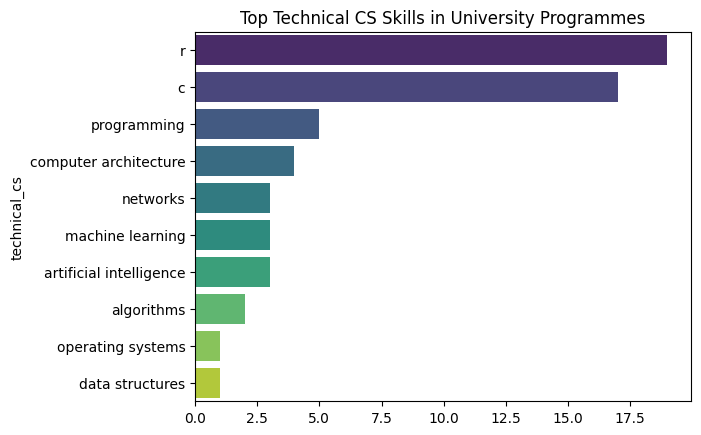

In [117]:
sns.barplot(x=top_cs.values, y=top_cs.index, palette="viridis")
plt.title("Top Technical CS Skills in University Programmes")
plt.show()


In [118]:
df_html["clean_text"].head()


,clean_text
0,assistive tools loop staff library vacancies w...
1,the first three years of the programme are the...
2,in their fourth year master in computer scienc...
3,mathematics computer programming microprocesso...
4,discrete mathematics algorithms data structure...


In [119]:
df_html[["technical_cs", "technical_business", "cognitive_skills", "social_skills"]].head(10)


,technical_cs,technical_business,cognitive_skills,social_skills
0,"[c, r]",[],[],[]
1,"[c, r]",[],[],[]
2,"[c, r, ai]",[],[],[]
3,"[c, r, computer programming, programming]",[],[],[]
4,"[c, r, data structures, algorithms, programmin...",[],[],[communication]
5,"[c, r, artificial intelligence, software engin...",[],[],[communication]
6,"[c, r, machine learning, programming, computer...",[],[],[]
7,"[c, r, machine learning, programming, computer...",[],[],[]
8,"[c, r, machine learning, artificial intelligen...",[data analysis],[analysis],[]
9,"[c, r]",[],[],[]


In [120]:
df_html.to_csv("university_skills_filtered.csv", index=False)


In [121]:
from google.colab import files
files.download("university_skills_filtered.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>